# Trabalho A2 — Data Science

**Alunos:** Arthur Ribeiro, Marcos Vitor, Gabriel Asserman e Eduardo Bernardes

## Análise de probabilidade em classificação binária

Objetivo: desenvolver um programa que produza um gráfico baseado em histogramas para 
analisar a distribuição das probabilidades previstas por um modelo de classificação 
binária e apoiar a definição de faixas de decisão.

Modelos de classificação binária normalmente não retornam apenas "0" ou "1" —
eles retornam a probabilidade estimada de uma instância pertencer à classe
positiva. Cabe a quem usa o modelo decidir, a partir dessa probabilidade,
onde ficam os pontos de corte que separam decisões automáticas de casos que
precisam de revisão manual.

**O que esta parte do notebook oferece:**

- `plot_histogram`: gera um histograma comparando a distribuição de
  probabilidades de toda a população com a distribuição apenas da classe
  positiva, já destacando visualmente as três faixas de decisão (negativo
  automático, análise manual, positivo automático).
- `assign_decision_band`: classifica cada instância em uma dessas três
  faixas, a partir de dois cortes `t1 < t2`.
- `decision_band_report`: gera o relatório numérico de cada faixa (percentual
  da população, proporção de positivos/negativos, e as proporções de erro de
  classificação automática, com o denominador de cada uma explícito).

**Reutilização:** as funções trabalham apenas com os rótulos reais (`y_true`)
e as probabilidades estimadas (`y_prob`) — não dependem de nenhum dataset ou
modelo específico. Os cortes `t1`/`t2` devem ser escolhidos observando dados
de **validação** e aplicados ao conjunto de **teste** sem novos ajustes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def assign_decision_band(y_prob, t1, t2):
    """
    Classifica cada instância em uma das 3 faixas de decisão, a partir de dois
    cortes t1 < t2 (definidos previamente com dados de VALIDAÇÃO).

    Retorna um array de strings, uma por instância:
    - "negativo_automatico": probabilidade < t1
    - "analise_manual":      t1 <= probabilidade < t2
    - "positivo_automatico": probabilidade >= t2
    """
    assert t1 < t2, "t1 precisa ser menor que t2"

    y_prob = np.asarray(y_prob)
    faixa = np.full(len(y_prob), "analise_manual", dtype=object)
    faixa[y_prob < t1] = "negativo_automatico"
    faixa[y_prob >= t2] = "positivo_automatico"
    return faixa


def plot_histogram(y_true, y_prob, t1, t2, positive_class_definition, bin_width_pct=10):
    """
    y_true: rótulos reais (0/1) das instâncias.
    y_prob: probabilidade estimada da classe positiva, para TODAS as instâncias
            (independente de y_true) — não filtrar por rótulo real antes de passar aqui.
    t1, t2: cortes (t1 < t2) que definem as 3 faixas de decisão, escolhidos
            previamente com dados de VALIDAÇÃO.
    positive_class_definition: string explicando o que "classe positiva" significa
            neste problema (ex: "é spam?", "é fraude?", "expressa sentimento positivo?").
    bin_width_pct: largura de cada intervalo do histograma, em pontos percentuais
            (ex: 10 -> intervalos de 0-10%, 10-20%, ..., 90-100%).

    Ao gerar os resultados finais do trabalho, chamar esta função apenas com
    y_true/y_prob do CONJUNTO DE TESTE — nunca com dados de treino ou validação.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    assert len(y_true) == len(y_prob), "cada instância precisa ter rótulo real e probabilidade correspondente"
    assert t1 < t2, "t1 precisa ser menor que t2"
    assert 100 % bin_width_pct == 0, "bin_width_pct precisa dividir 100 igualmente (ex: 5, 10, 20, 25)"

    y_prob_pct = y_prob * 100
    total_instancias = len(y_prob_pct)

    n_bins = 100 // bin_width_pct
    bin_edges = np.linspace(0, 100, n_bins + 1)  # bins meio-abertos: cada instância cai em exatamente um intervalo
    centros = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Mesmos bin_edges para as duas distribuições, para que sejam comparáveis ponto a ponto
    contagem_total, _ = np.histogram(y_prob_pct, bins=bin_edges)
    contagem_positiva, _ = np.histogram(y_prob_pct[y_true == 1], bins=bin_edges)

    # Mesmo denominador (total_instancias) nas duas — o vermelho é um subconjunto do azul,
    # nunca deve ser normalizado pelo próprio total de positivos.
    pct_total = contagem_total / total_instancias * 100
    pct_positiva = contagem_positiva / total_instancias * 100

    t1_pct, t2_pct = t1 * 100, t2 * 100
    faixa = assign_decision_band(y_prob, t1, t2)
    pct_por_faixa = {nome: (faixa == nome).sum() / total_instancias * 100 for nome in
                      ["negativo_automatico", "analise_manual", "positivo_automatico"]}

    largura_barra = bin_width_pct * 0.4

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.axvspan(0, t1_pct, color="gray", alpha=0.12)
    ax.axvspan(t1_pct, t2_pct, color="gold", alpha=0.15)
    ax.axvspan(t2_pct, 100, color="green", alpha=0.12)

    ax.bar(centros - largura_barra / 2, pct_total, width=largura_barra,
           color="blue", hatch="//", edgecolor="blue", fill=False, label="Todas as instâncias")
    ax.bar(centros + largura_barra / 2, pct_positiva, width=largura_barra,
           color="red", hatch="//", edgecolor="red", fill=False,
           label=f"Classe positiva ({positive_class_definition})")

    ax.axvline(t1_pct, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(t2_pct, color="black", linestyle="--", linewidth=1.5)

    y_topo = max(pct_total.max(), pct_positiva.max()) * 1.3
    ax.set_ylim(0, y_topo)
    rotulos = {
        "negativo_automatico": ("Negativo automático", (0 + t1_pct) / 2),
        "analise_manual": ("Análise manual", (t1_pct + t2_pct) / 2),
        "positivo_automatico": ("Positivo automático", (t2_pct + 100) / 2),
    }
    for nome, (titulo, x_centro) in rotulos.items():
        ax.text(x_centro, y_topo * 0.97, f"{titulo}\n{pct_por_faixa[nome]:.1f}% da população",
                ha="center", va="top", fontsize=9)

    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Instâncias do conjunto avaliado (%)")
    ax.set_xlim(0, 100)
    ax.set_xticks(sorted(set(bin_edges) | {t1_pct, t2_pct}))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout()
    plt.show()

    return fig, ax

In [2]:
import pandas as pd


def decision_band_report(y_true, y_prob, t1, t2):
    """
    Aplica os cortes t1/t2 (já definidos com dados de VALIDAÇÃO) ao conjunto
    passado aqui (deve ser o conjunto de TESTE) e monta o relatório exigido:
    percentual da população por faixa, positivos/negativos por faixa, e as
    duas proporções de erro automatizado, cada uma com seu denominador.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    faixa = assign_decision_band(y_prob, t1, t2)

    total = len(y_prob)
    total_positivos_reais = (y_true == 1).sum()
    total_negativos_reais = (y_true == 0).sum()

    linhas = []
    for nome_faixa in ["negativo_automatico", "analise_manual", "positivo_automatico"]:
        na_faixa = faixa == nome_faixa
        n = na_faixa.sum()
        pos = ((y_true == 1) & na_faixa).sum()
        neg = ((y_true == 0) & na_faixa).sum()
        linhas.append({
            "Faixa": nome_faixa,
            "Instâncias": n,
            "% da população (n / total_teste)": round(n / total * 100, 2),
            "Positivos reais": pos,
            "% positivos na faixa (pos / n)": round(pos / n * 100, 2) if n else float("nan"),
            "Negativos reais": neg,
            "% negativos na faixa (neg / n)": round(neg / n * 100, 2) if n else float("nan"),
        })
    tabela = pd.DataFrame(linhas)

    # Denominador: total de POSITIVOS REAIS (não o tamanho da faixa, não o total geral)
    positivos_perdidos = ((y_true == 1) & (faixa == "negativo_automatico")).sum()
    prop_positivos_perdidos = positivos_perdidos / total_positivos_reais

    # Denominador: total de NEGATIVOS REAIS (não o tamanho da faixa, não o total geral)
    negativos_mal_classificados = ((y_true == 0) & (faixa == "positivo_automatico")).sum()
    prop_negativos_mal_classificados = negativos_mal_classificados / total_negativos_reais

    print("Relatório por faixa de decisão (conjunto de teste):")
    display(tabela)
    print(
        f"\nPositivos reais classificados automaticamente como negativos: "
        f"{positivos_perdidos}/{total_positivos_reais} "
        f"({prop_positivos_perdidos * 100:.2f}%; denominador = total de positivos reais)"
    )
    print(
        f"Negativos reais classificados automaticamente como positivos: "
        f"{negativos_mal_classificados}/{total_negativos_reais} "
        f"({prop_negativos_mal_classificados * 100:.2f}%; denominador = total de negativos reais)"
    )

    return tabela

# Heart Failure Prediction Dataset

**Responsável pelo caso:** Eduardo Bernardes

**Fonte:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

**Owner:** fedesoriano

**Licença:** Open Database License (ODbL)

**Descrição:** base de dados clínica com 918 pacientes, combinando registros
de 5 bases distintas (Cleveland, Hungarian, Switzerland, Long Beach VA e
Statlog Heart). Cada linha representa um paciente, descrito por indicadores
clínicos como idade, sexo, tipo de dor no peito, pressão arterial em
repouso, colesterol, glicemia em jejum, resultado do eletrocardiograma em
repouso, frequência cardíaca máxima atingida, angina induzida por exercício
e depressão do segmento ST. O objetivo é prever se o paciente tem ou não
doença cardíaca.

**Variável-Alvo:** `HeartDisease` — **Classe Positiva:** 1 = "o paciente tem doença cardíaca".

In [3]:
import pandas as pd

df = pd.read_csv('./data/heart.csv', sep =',')
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Identificamos nossa variável-alvo e não precisaremos fazer nenhuma mudança,
pois o valor já vem formatado em 0 e 1 (binário).

Verificação do percentual de balanceamento.

Isso é muito importante pois existe um grande gap entre bases desbalanceadas
e balanceadas. Bases balanceadas são aquelas que têm valores positivos e
negativos em proporções parecidas — isso mostra que o erro, independente do
lado, tem consequências semelhantes. Bases desbalanceadas, onde temos uma
classe rara, exigem que usemos métricas e tomemos decisões de forma
diferente (como já discutimos: acurácia sozinha enganaria nesse cenário).

In [4]:
contagem_classes = df.groupby('HeartDisease')['HeartDisease'].count()
porcentagem_classes = contagem_classes / contagem_classes.sum() * 100
print(porcentagem_classes)

HeartDisease
0    44.662309
1    55.337691
Name: HeartDisease, dtype: float64


A base está bem balanceada (44,7% classe 0 / 55,3% classe 1) — bem diferente
do desbalanceamento extremo visto no spam do professor (86,6%/13,4%). Isso
significa que a acurácia deixa de ser uma métrica enganosa aqui, já que não
existe uma classe "rara" escondendo o desempenho real do modelo.

Porém, balanceamento de classes e custo do erro são coisas diferentes. Mesmo
com a base balanceada, os dois tipos de erro **não têm o mesmo custo** neste
domínio:

- **Falso negativo** (dizer que o paciente não tem doença cardíaca quando na
  verdade tem) é o erro mais grave: o paciente sai sem tratamento, achando
  que está saudável, e o problema pode se agravar sem que ninguém perceba.
- **Falso positivo** (dizer que o paciente tem doença cardíaca quando não
  tem) é um erro mais barato: na pior das hipóteses, o paciente faz alguns
  exames extras para confirmar que está tudo bem.

Por isso, mesmo com a base balanceada, vamos priorizar minimizar falsos
negativos ao escolher os cortes `t1`/`t2` — preferindo encaminhar mais casos
para análise manual (faixa intermediária) a arriscar automatizar uma
classificação negativa que pode estar errada.

### 1. Qualidade dos dados

Antes de treinar, conferimos se os valores fazem sentido clinicamente.
Duas colunas têm valores **zero**, que são fisiologicamente impossíveis
para um paciente vivo:

- `Cholesterol = 0` (colesterol sérico em mg/dl)
- `RestingBP = 0` (pressão arterial em repouso em mm Hg)

In [5]:
zeros_colesterol = df['Cholesterol'] == 0
zeros_pressao = df['RestingBP'] == 0

print(f"Cholesterol = 0: {zeros_colesterol.sum()} pacientes "
      f"({zeros_colesterol.mean() * 100:.1f}% da base)")
print(f"RestingBP   = 0: {zeros_pressao.sum()} paciente(s)")

# Taxa de doença cardíaca entre quem tem colesterol zerado x quem tem valor real
print(f"\n% com doença cardíaca quando Cholesterol = 0: "
      f"{df.loc[zeros_colesterol, 'HeartDisease'].mean() * 100:.1f}%")
print(f"% com doença cardíaca quando Cholesterol > 0: "
      f"{df.loc[~zeros_colesterol, 'HeartDisease'].mean() * 100:.1f}%")

Cholesterol = 0: 172 pacientes (18.7% da base)
RestingBP   = 0: 1 paciente(s)

% com doença cardíaca quando Cholesterol = 0: 88.4%
% com doença cardíaca quando Cholesterol > 0: 47.7%


**O que isso mostra:** 172 pacientes (18,7%) estão com colesterol zerado, e
88% deles têm doença cardíaca, contra 48% do restante. Isso não é
fisiologia: o dataset junta 5 bases hospitalares, e algumas delas
(principalmente a da Suíça) simplesmente **não registraram** o colesterol e
gravaram 0 no lugar. Como essas bases tinham muitos pacientes doentes, o
zero virou um "atalho" para a classe positiva.

**Decisão:** tratar esses zeros como **valor ausente** (`NaN`) e preencher
com a **mediana calculada só no treino**.

Por que não as outras opções:

- **Manter o 0:** o modelo aprenderia a regra "colesterol não medido =
  doente", que só vale para este dataset. Num hospital novo, que mede o
  colesterol de todo mundo, essa regra não existiria.
- **Apagar as linhas:** perderíamos 18,7% da base, e justamente uma parte
  onde quase todos são positivos, o que distorceria a proporção das classes.
- **Mediana em vez de média:** o colesterol tem valores extremos (até 603
  mg/dl) e a mediana não é puxada por eles.
- **Só no treino:** se a mediana fosse calculada com a base inteira,
  informação da validação e do teste "vazaria" para o treinamento
  (*data leakage*). Por isso o preenchimento fica dentro do `Pipeline`
  (seção 3), que aprende a mediana apenas com os dados de treino.

In [6]:
import numpy as np

df_modelo = df.copy()
df_modelo['Cholesterol'] = df_modelo['Cholesterol'].replace(0, np.nan)
df_modelo['RestingBP'] = df_modelo['RestingBP'].replace(0, np.nan)

print("Valores ausentes após a conversão:")
print(df_modelo[['Cholesterol', 'RestingBP']].isna().sum())

Valores ausentes após a conversão:
Cholesterol    172
RestingBP        1
dtype: int64


### 2. Separação em treino, validação e teste

O enunciado exige que os cortes `t1`/`t2` sejam escolhidos na **validação**
e aplicados ao **teste** sem ajuste. Por isso separamos a base em três
partes (60% / 20% / 20%):

| Conjunto | Para que serve |
|---|---|
| **Treino** (60%) | o modelo aprende os padrões e os hiperparâmetros são escolhidos (validação cruzada dentro dele) |
| **Validação** (20%) | olhamos o histograma e escolhemos `t1` e `t2` |
| **Teste** (20%) | usado **uma única vez**, no final, para medir o resultado honesto dos cortes |

Se escolhêssemos os cortes olhando o teste, o resultado ficaria otimista
demais, porque os cortes seriam "feitos sob medida" para aqueles pacientes.

`stratify` mantém a mesma proporção de doentes (~55%) nos três conjuntos, e
`random_state=42` garante que a divisão seja sempre a mesma.

In [7]:
from sklearn.model_selection import train_test_split

atributos_numericos = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
atributos_categoricos = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X = df_modelo[atributos_numericos + atributos_categoricos]
y = df_modelo['HeartDisease']

# 1ª divisão: 60% treino, 40% separado
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
# 2ª divisão: os 40% viram 20% validação + 20% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

for nome, alvo in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    print(f"{nome:10s} {len(alvo):4d} pacientes | {alvo.mean() * 100:.1f}% com doença cardíaca")

Treino      550 pacientes | 55.3% com doença cardíaca
Validação   184 pacientes | 55.4% com doença cardíaca
Teste       184 pacientes | 55.4% com doença cardíaca


### 3. Pré-processamento

O modelo só entende números, então:

- **Atributos numéricos** (`Age`, `RestingBP`, `Cholesterol`, `FastingBS`,
  `MaxHR`, `Oldpeak`): passam pelo `SimpleImputer(strategy="median")`, que
  preenche os ausentes da seção 1.
- **Atributos categóricos** (`Sex`, `ChestPainType`, `RestingECG`,
  `ExerciseAngina`, `ST_Slope`): viram colunas 0/1 com `OneHotEncoder`
  (ex.: `ST_Slope` vira `ST_Slope_Up`, `ST_Slope_Flat`, `ST_Slope_Down`). Não
  usamos números 0, 1, 2 direto porque isso criaria uma ordem que não existe
  (o tipo de dor "ASY" não é "maior" que "ATA").

**Não normalizamos** as colunas numéricas (`StandardScaler`): o Random Forest
é formado por árvores de decisão, que só perguntam "valor > corte?". Mudar a
escala de uma coluna não muda a ordem dos valores, então não muda nenhuma
divisão da árvore.

Tudo fica dentro de um `Pipeline`: quando o modelo é treinado, o imputador
e o encoder aprendem **só com os dados de treino** e depois apenas aplicam o
que aprenderam na validação e no teste (mesmo princípio do `fit_transform` /
`transform` do TF-IDF no notebook do spam).

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessamento = ColumnTransformer([
    ('numericos', SimpleImputer(strategy='median'), atributos_numericos),
    # handle_unknown='ignore': se aparecer uma categoria nova no teste, vira tudo 0 em vez de dar erro
    ('categoricos', OneHotEncoder(handle_unknown='ignore'), atributos_categoricos),
])

pipeline = Pipeline([
    ('preprocessamento', preprocessamento),
    ('modelo', RandomForestClassifier(random_state=42, n_jobs=1)),
])

### 4. Treinamento do modelo

Seguimos a mesma receita do notebook do spam: **Random Forest** com busca
aleatória de hiperparâmetros (`RandomizedSearchCV`) e validação cruzada
estratificada em 5 partes, usando **somente o treino**.

Duas diferenças em relação ao spam, e o porquê de cada uma:

1. **Métrica da busca = `roc_auc` (e não `f1`).** O F1 é calculado com o
   corte padrão de 0,5, e nós não vamos usar 0,5: vamos escolher `t1`/`t2`
   depois. O que interessa aqui é o modelo **ordenar bem** os pacientes, ou
   seja, dar probabilidade maior para quem é doente do que para quem não é.
   A ROC-AUC mede exatamente isso, sem depender de corte nenhum.
2. **Sem `class_weight="balanced"`.** No spam, só 13% eram positivos e o
   peso servia para o modelo não ignorar a classe rara. Aqui a base é
   balanceada (55% / 45%): o peso seria ~0,9 para uma classe e ~1,1 para a
   outra, praticamente sem efeito. Numa base desbalanceada (como a de AVC do
   grupo), esse ajuste faz diferença; aqui não é necessário.

A grade inclui árvores **rasas** (`max_depth` 3 e 5) e folhas maiores
(`min_samples_leaf` até 8) porque o treino tem só 550 pacientes: árvores
muito profundas decorariam os pacientes do treino (*overfitting*).

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

parametros = {
    'modelo__n_estimators': [200, 300, 500, 700],
    'modelo__max_depth': [None, 3, 5, 10, 20],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4, 8],
    'modelo__max_features': ['sqrt', 'log2', 0.3, 0.5],
    'modelo__criterion': ['gini', 'entropy'],
}

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

busca = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=parametros,
    n_iter=30,
    scoring='roc_auc',
    cv=validacao_cruzada,
    refit=True,          # ao final, retreina a melhor combinação com o treino inteiro
    n_jobs=-1,
    random_state=42,
)

busca.fit(X_train, y_train)
melhor_modelo = busca.best_estimator_

print("Melhores hiperparâmetros:")
for nome, valor in busca.best_params_.items():
    print(f"  {nome.replace('modelo__', '')}: {valor}")
print(f"\nROC-AUC médio na validação cruzada (treino): {busca.best_score_:.4f}")

Melhores hiperparâmetros:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 5
  criterion: gini

ROC-AUC médio na validação cruzada (treino): 0.9185


A busca preferiu árvores rasas e folhas com vários pacientes. Além de
evitar *overfitting*, isso deixa as probabilidades mais **graduais**: uma
árvore muito profunda termina em folhas "puras" e responde quase sempre 0%
ou 100%, o que deixaria o histograma sem meio-termo para analisar.

### 5. Probabilidades na validação

Agora o modelo calcula, para cada paciente da validação, a probabilidade de
ele ter doença cardíaca (`predict_proba`, coluna da classe 1).

Como referência, mostramos também as métricas usando o corte padrão de 0,5.
Numa base balanceada a **acurácia** é uma métrica confiável: não existe uma
classe rara que o modelo possa ignorar e ainda assim ter acurácia alta (no
spam, chutar "não é spam" para tudo já dava 86,6% de acurácia).

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Posição da classe positiva (1 = tem doença cardíaca) nas colunas do predict_proba
indice_positivo = list(melhor_modelo.classes_).index(1)

y_prob_val = melhor_modelo.predict_proba(X_val)[:, indice_positivo]
y_pred_val_05 = (y_prob_val >= 0.5).astype(int)

metricas_val = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-score', 'ROC-AUC'],
    'Validação (corte 0,5)': [
        accuracy_score(y_val, y_pred_val_05),
        precision_score(y_val, y_pred_val_05),
        recall_score(y_val, y_pred_val_05),
        f1_score(y_val, y_pred_val_05),
        roc_auc_score(y_val, y_prob_val),
    ],
})
display(metricas_val.round(4))

,Métrica,"Validação (corte 0,5)"
0,Acurácia,0.8859
1,Precisão,0.9010
2,Recall,0.8922
3,F1-score,0.8966
4,ROC-AUC,0.9360


Com o corte padrão de 0,5 o **recall** fica em ~89%: cerca de **1 em cada
10 doentes** seria dado como saudável. Para cardiologia isso é alto demais,
e é por isso que trocamos o corte único por duas faixas com uma zona de
análise manual no meio.

### 6. Escolha dos cortes `t1` e `t2`

Primeiro definimos o que cada faixa **significa na prática** em um
consultório. O modelo funciona como uma **triagem**, não como diagnóstico:

| Faixa | O que acontece com o paciente | Erro possível | Gravidade |
|---|---|---|---|
| **Negativo automático** (`prob < t1`) | é liberado sem passar pelo cardiologista | doente liberado (**falso negativo**) | **muito grave**: a doença avança sem tratamento |
| **Análise manual** (`t1 ≤ prob < t2`) | cardiologista avalia o caso | nenhum automático (custo = tempo do médico) | - |
| **Positivo automático** (`prob ≥ t2`) | vai direto para exames confirmatórios (ecocardiograma, teste ergométrico...) | saudável faz exames à toa (**falso positivo**) | leve: custo e incômodo dos exames |

Como os dois erros têm gravidades bem diferentes, as tolerâncias são
diferentes, e foram fixadas **antes** de olhar os resultados:

- **`t1`:** no máximo **2% dos doentes reais** podem cair no negativo
  automático. Escolhemos o **maior** `t1` que respeita isso (quanto maior o
  `t1`, mais pacientes saudáveis são liberados sem ocupar o médico).
- **`t2`:** no máximo **5% dos saudáveis reais** podem cair no positivo
  automático. Escolhemos o **menor** `t2` que respeita isso (quanto menor o
  `t2`, mais doentes vão direto para os exames sem esperar pelo médico).

Os cortes candidatos vão de 5 em 5 pontos percentuais. Um ajuste mais fino
(de 1 em 1) acabaria "decorando" pacientes específicos da validação, que tem
só 184 pessoas.

Em termos de precisão e recall: o `t1` controla o **recall** da triagem
(quantos doentes são pegos antes de serem liberados), e o `t2` controla a
**precisão** do positivo automático (quantos dos encaminhados direto são de
fato doentes). Aqui aceitamos muito mais sacrificar a automação do que o
recall.

In [11]:
def proporcoes_de_erro(y_true, y_prob, t1, t2):
    """
    Aplica os cortes com assign_decision_band e devolve as duas proporções de
    erro automático do relatório, mais o tamanho de cada faixa.
    """
    y_true = np.asarray(y_true)
    faixa = assign_decision_band(y_prob, t1, t2)
    return {
        # denominador = total de POSITIVOS reais
        'positivos_perdidos': ((y_true == 1) & (faixa == 'negativo_automatico')).sum() / (y_true == 1).sum(),
        # denominador = total de NEGATIVOS reais
        'negativos_mal_classificados': ((y_true == 0) & (faixa == 'positivo_automatico')).sum() / (y_true == 0).sum(),
        'pct_negativo_automatico': (faixa == 'negativo_automatico').mean(),
        'pct_analise_manual': (faixa == 'analise_manual').mean(),
        'pct_positivo_automatico': (faixa == 'positivo_automatico').mean(),
    }


TOLERANCIA_POSITIVOS_PERDIDOS = 0.02   # t1: no máximo 2% dos doentes liberados
TOLERANCIA_NEGATIVOS_ERRADOS = 0.05    # t2: no máximo 5% dos saudáveis encaminhados à toa

cortes_candidatos = np.round(np.arange(0.05, 1.0, 0.05), 2)

# Cada corte é testado sozinho: "positivos perdidos" só depende de t1 e
# "negativos mal classificados" só depende de t2. O outro corte fica no extremo.
linhas = []
for corte in cortes_candidatos:
    como_t1 = proporcoes_de_erro(y_val, y_prob_val, t1=corte, t2=1.0)
    como_t2 = proporcoes_de_erro(y_val, y_prob_val, t1=0.0, t2=corte)
    linhas.append({
        'Corte': corte,
        'Se t1: % doentes liberados': como_t1['positivos_perdidos'] * 100,
        'Se t1: % população liberada': como_t1['pct_negativo_automatico'] * 100,
        'Se t2: % saudáveis encaminhados': como_t2['negativos_mal_classificados'] * 100,
        'Se t2: % população encaminhada': como_t2['pct_positivo_automatico'] * 100,
    })
tabela_cortes = pd.DataFrame(linhas)
display(tabela_cortes.round({c: 1 for c in tabela_cortes.columns if c != 'Corte'}))

t1 = tabela_cortes.loc[
    tabela_cortes['Se t1: % doentes liberados'] <= TOLERANCIA_POSITIVOS_PERDIDOS * 100, 'Corte'
].max()
t2 = tabela_cortes.loc[
    tabela_cortes['Se t2: % saudáveis encaminhados'] <= TOLERANCIA_NEGATIVOS_ERRADOS * 100, 'Corte'
].min()
assert t1 < t2, "as tolerâncias escolhidas deixaram t1 >= t2"

print(f"t1 escolhido = {t1:.2f}  |  t2 escolhido = {t2:.2f}")

,Corte,Se t1: % doentes liberados,Se t1: % população liberada,Se t2: % saudáveis encaminhados,Se t2: % população encaminhada
0,0.05,0.0,10.3,76.8,89.7
1,0.10,2.0,18.5,61.0,81.5
2,0.15,2.9,22.3,53.7,77.7
3,0.20,5.9,27.2,46.3,72.8
4,0.25,5.9,32.6,34.1,67.4
5,0.30,6.9,35.3,29.3,64.7
6,0.35,6.9,38.6,22.0,61.4
7,0.40,8.8,40.8,19.5,59.2
8,0.45,9.8,42.9,15.9,57.1
9,0.50,10.8,45.1,12.2,54.9


t1 escolhido = 0.10  |  t2 escolhido = 0.65


Na tabela dá para ver o dilema:

- **`t1 = 0,10`**: libera 18,5% da população sem médico, e 2 dos 102
  doentes da validação (1,96%) caem nessa faixa, no limite da tolerância.
  Subir para 0,15 liberaria mais ~4% da população, mas os doentes liberados
  iriam para 2,9%, acima do aceitável.
- **`t2 = 0,65`**: 3,7% dos saudáveis (3 de 82) iriam fazer exames à toa.
  Descer para 0,60 encaminharia mais pacientes direto, mas esse número
  subiria para 6,1%, acima dos 5%.

O histograma abaixo mostra a mesma decisão na **validação** (é esta a
visualização usada para escolher os cortes; o resultado final vem só no
teste, na seção 8):

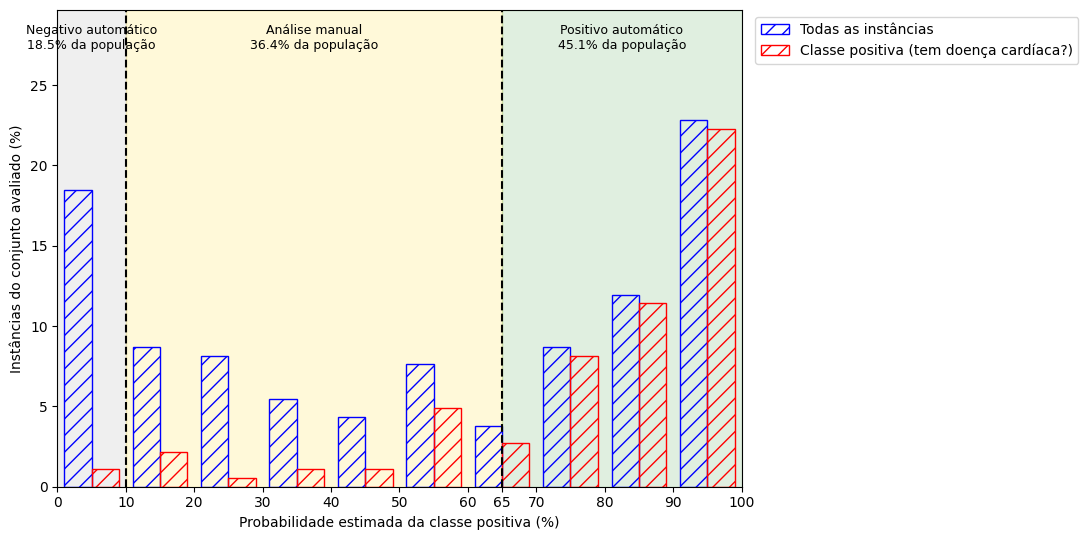

In [12]:
fig, ax = plot_histogram(
    y_val, y_prob_val, t1=t1, t2=t2,
    positive_class_definition="tem doença cardíaca?",
    bin_width_pct=10,
)

**Leitura do histograma (validação):**

- Na faixa de 0-10% a barra vermelha é mínima (2 doentes entre 34
  pacientes): o modelo tem bastante certeza sobre esses pacientes
  saudáveis, por isso eles podem ser liberados automaticamente.
- Nas faixas de 70-100% quase toda a barra azul é vermelha: são os doentes
  que o modelo identifica com segurança.
- No meio (10-65%) azul e vermelho se misturam. É onde o modelo "não sabe",
  e é exatamente a faixa que mandamos para o cardiologista.

Como a base é **balanceada**, a barra vermelha é grande em todo o lado
direito do gráfico. Numa base desbalanceada (ex.: AVC com ~5% de
positivos), a barra vermelha seria pequena em todo o gráfico e o desafio
seria achar os poucos positivos no meio de muitos negativos.

### 7. Comparando cenários de corte (validação)

Para justificar a escolha, comparamos o cenário escolhido com duas
alternativas extremas, sempre na validação:

- **Máxima automação** (`t1 = 0,45`, `t2 = 0,55`): quase ninguém vai para o
  médico. É o que aconteceria usando praticamente só o corte padrão de 0,5.
- **Escolhido** (`t1`, `t2` da seção 6).
- **Ultra conservador** (`t1 = 0,05`, `t2 = 0,90`): só automatiza quando o
  modelo tem quase certeza.

In [13]:
cenarios = {
    'Máxima automação': (0.45, 0.55),
    'Escolhido': (t1, t2),
    'Ultra conservador': (0.05, 0.90),
}

linhas = []
for nome, (c1, c2) in cenarios.items():
    r = proporcoes_de_erro(y_val, y_prob_val, c1, c2)
    linhas.append({
        'Cenário': nome,
        't1': c1,
        't2': c2,
        '% negativo automático': r['pct_negativo_automatico'] * 100,
        '% análise manual': r['pct_analise_manual'] * 100,
        '% positivo automático': r['pct_positivo_automatico'] * 100,
        '% doentes liberados (÷ positivos)': r['positivos_perdidos'] * 100,
        '% saudáveis encaminhados (÷ negativos)': r['negativos_mal_classificados'] * 100,
    })
tabela_cenarios = pd.DataFrame(linhas)
display(tabela_cenarios.round({c: 1 for c in tabela_cenarios.columns if c not in ('t1', 't2')}))

,Cenário,t1,t2,% negativo automático,% análise manual,% positivo automático,% doentes liberados (÷ positivos),% saudáveis encaminhados (÷ negativos)
0,Máxima automação,0.45,0.55,42.9,3.8,53.3,9.8,9.8
1,Escolhido,0.10,0.65,18.5,36.4,45.1,2.0,3.7
2,Ultra conservador,0.05,0.90,10.3,66.8,22.8,0.0,1.2


**Conclusão da comparação:**

- **Máxima automação**: o médico só vê ~4% dos pacientes, mas **1 em cada
  10 doentes** é mandado para casa como saudável. Em cardiologia isso é
  inaceitável.
- **Ultra conservador**: nenhum doente é liberado, mas **2 de cada 3
  pacientes** voltam para o médico e o modelo quase não ajuda. Para evitar
  os 2 doentes liberados do cenário escolhido, o médico teria que avaliar
  quase o dobro de pacientes.
- **Escolhido**: fica dentro das duas tolerâncias e automatiza quase 2/3
  dos casos (18,5% liberados sem médico + 45,1% direto para os exames).

O preço é que pouco mais de 1/3 dos pacientes ainda precisa de análise
manual. Nesse domínio, preferimos pagar com tempo de médico a pagar com
doentes sem tratamento.

### 8. Resultado final no conjunto de teste

Os cortes estão **congelados** (`t1` e `t2` da seção 6). Agora aplicamos o
modelo e os cortes no teste, que não foi usado em nenhuma decisão até aqui.
Este é o resultado que representa como o sistema se comportaria com
pacientes novos.

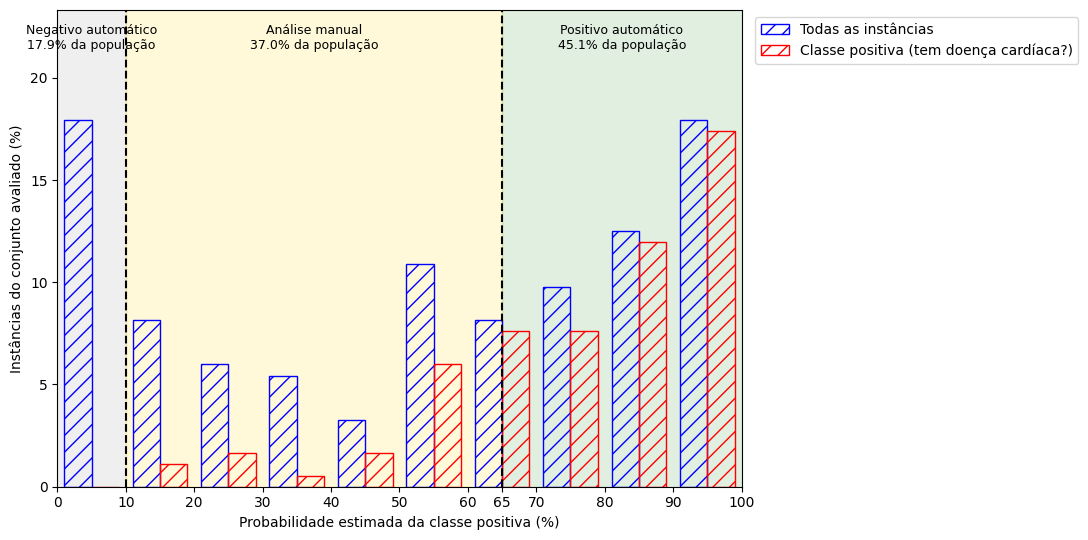

Relatório por faixa de decisão (conjunto de teste):


,Faixa,Instâncias,% da população (n / total_teste),Positivos reais,% positivos na faixa (pos / n),Negativos reais,% negativos na faixa (neg / n)
0,negativo_automatico,33,17.93,0,0.00,33,100.00
1,analise_manual,68,36.96,25,36.76,43,63.24
2,positivo_automatico,83,45.11,77,92.77,6,7.23



Positivos reais classificados automaticamente como negativos: 0/102 (0.00%; denominador = total de positivos reais)
Negativos reais classificados automaticamente como positivos: 6/82 (7.32%; denominador = total de negativos reais)


In [14]:
y_prob_test = melhor_modelo.predict_proba(X_test)[:, indice_positivo]

fig, ax = plot_histogram(
    y_test, y_prob_test, t1=t1, t2=t2,
    positive_class_definition="tem doença cardíaca?",
    bin_width_pct=10,
)

tabela_teste = decision_band_report(y_test, y_prob_test, t1=t1, t2=t2)

In [15]:
# Validação x teste: se os números forem parecidos, os cortes generalizam
comparacao = pd.DataFrame([
    {'Conjunto': 'Validação', 'ROC-AUC': roc_auc_score(y_val, y_prob_val),
     **{k: v * 100 for k, v in proporcoes_de_erro(y_val, y_prob_val, t1, t2).items()}},
    {'Conjunto': 'Teste', 'ROC-AUC': roc_auc_score(y_test, y_prob_test),
     **{k: v * 100 for k, v in proporcoes_de_erro(y_test, y_prob_test, t1, t2).items()}},
])
display(comparacao.round(2))

,Conjunto,ROC-AUC,positivos_perdidos,negativos_mal_classificados,pct_negativo_automatico,pct_analise_manual,pct_positivo_automatico
0,Validação,0.94,1.96,3.66,18.48,36.41,45.11
1,Teste,0.93,0.00,7.32,17.93,36.96,45.11


**Leitura do resultado no teste:**

- **ROC-AUC** de 0,93 no teste contra 0,94 na validação: o modelo
  generaliza para pacientes novos.
- **Tamanho das faixas** praticamente idêntico ao da validação (≈18% /
  37% / 45%): a divisão de trabalho entre modelo e médico se mantém.
- **Doentes liberados automaticamente: 0 de 102.** O erro grave, que era
  a nossa prioridade, não aconteceu no teste. Todos os 33 pacientes
  liberados eram de fato saudáveis.
- **Saudáveis encaminhados à toa: 6 de 82 (7,3%)**, acima da tolerância de
  5% que tinha sido atingida na validação (3 de 82). A diferença é de 3
  pacientes: com só 82 saudáveis em cada conjunto, cada paciente vale ~1,2
  ponto percentual, então os percentuais oscilam bastante de um conjunto
  para o outro. Esse é o erro **barato** (exames a mais), justamente o que
  aceitamos tolerar mais.
- **Não reajustamos o `t2` depois de ver o teste.** Se fizéssemos isso,
  estaríamos escolhendo o corte com o teste, e ele deixaria de ser uma
  medida honesta. O resultado correto a reportar é este: com os cortes
  escolhidos na validação, o sistema não deixou nenhum doente escapar e
  encaminhou 7,3% dos saudáveis para exames desnecessários.

### 9. Quais características mais pesam na decisão (SHAP)

Assim como no notebook do spam, usamos o SHAP para ver quais atributos
empurram a probabilidade para cima (doença) ou para baixo (saudável). Cada
ponto é um paciente do teste; a cor indica se o valor do atributo é alto
(vermelho) ou baixo (azul); à direita do zero = aumenta a probabilidade
de doença cardíaca.

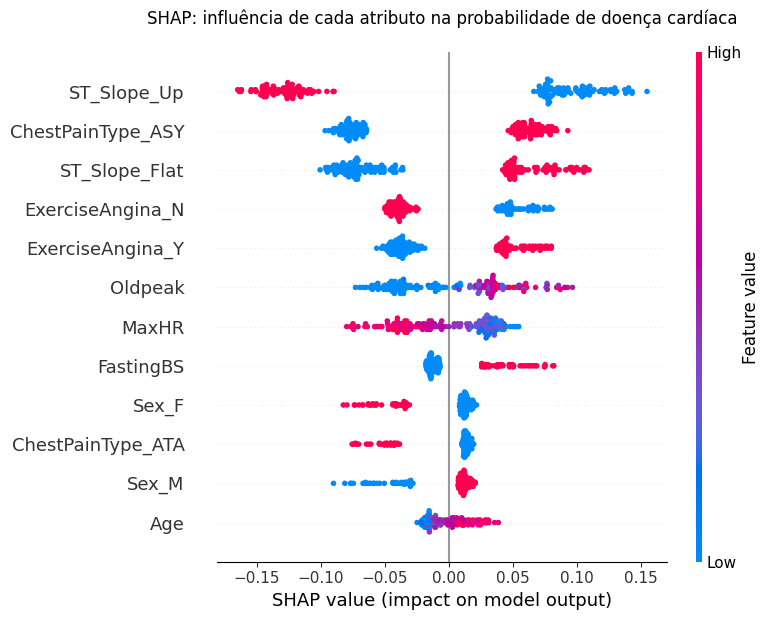

In [16]:
import warnings
warnings.filterwarnings('ignore', message='IProgress not found')  # aviso visual do tqdm, não afeta o cálculo
import shap

# O SHAP explica o Random Forest, que recebe os dados já pré-processados
preprocessador_treinado = melhor_modelo.named_steps['preprocessamento']
floresta = melhor_modelo.named_steps['modelo']

X_test_transformado = pd.DataFrame(
    preprocessador_treinado.transform(X_test),
    columns=[
        nome.replace('numericos__', '').replace('categoricos__', '')
        for nome in preprocessador_treinado.get_feature_names_out()
    ],
)

explainer = shap.TreeExplainer(floresta)
valores_shap = explainer(X_test_transformado)

# Em classificação binária o SHAP pode devolver uma dimensão por classe: ficamos com a classe 1
if valores_shap.values.ndim == 3:
    valores_positivo = valores_shap.values[:, :, indice_positivo]
else:
    valores_positivo = valores_shap.values

shap.summary_plot(valores_positivo, X_test_transformado, max_display=12, show=False)
plt.title("SHAP: influência de cada atributo na probabilidade de doença cardíaca", pad=20)
plt.tight_layout()
plt.show()

Os atributos que mais pesam fazem sentido clínico:

- **`ST_Slope_Up`** (inclinação ascendente do segmento ST no esforço) é o
  padrão de um coração saudável e puxa a probabilidade para baixo; o
  segmento ST plano (`ST_Slope_Flat`) puxa para cima.
- **`ChestPainType_ASY`** (dor no peito assintomática): é justamente a
  categoria com mais doentes na base (79%), porque a doença coronária muitas
  vezes não dá a dor "típica".
- **`Oldpeak`** alto (depressão do segmento ST) e **`ExerciseAngina_Y`**
  (angina durante esforço) aumentam a probabilidade.
- **`MaxHR`** baixo (frequência cardíaca máxima mais baixa no teste de
  esforço) e **`FastingBS = 1`** (glicemia em jejum alta) aumentam a
  probabilidade.
- **`Sex_F`** reduz a probabilidade: na base, 26% das mulheres têm doença
  cardíaca contra 63% dos homens.

O **colesterol nem aparece** entre os 12 atributos mais importantes. Isso
confirma que o tratamento da seção 1 funcionou: sem ele, o zero de
colesterol seria um "atalho" forte para a classe positiva e o modelo
estaria aprendendo um artefato da coleta, não um sinal médico.

### 10. Conclusão do caso Heart Failure (base balanceada)

- **Base balanceada (55% / 45%)**: a acurácia é confiável e não foi
  preciso usar `class_weight` nem gerar dados sintéticos; o modelo já vê
  exemplos suficientes das duas classes.
- **Balanceamento ≠ custo do erro**: mesmo com classes equilibradas, o
  falso negativo (doente liberado) é muito mais grave que o falso positivo
  (exame a mais). Por isso os cortes são **assimétricos**: `t1` bem baixo e
  tolerância de 2% para doentes perdidos, contra 5% para saudáveis
  encaminhados.
- **Resultado no teste**: o sistema automatiza 63% dos pacientes (18%
  liberados + 45% encaminhados direto), **nenhum doente foi liberado** e
  37% vão para o cardiologista. O custo foi 7,3% dos saudáveis fazendo
  exames a mais, acima da meta de 5%, mas no tipo de erro menos grave.
- **Contraste com a base desbalanceada**: aqui a dificuldade não é achar a
  classe rara, e sim decidir **quanto** automatizar dado que os erros têm
  custos diferentes. No caso desbalanceado, o problema principal é o modelo
  nem enxergar os positivos.

**Limitações:**

- A validação e o teste têm 184 pacientes cada; um único paciente muda os
  percentuais em ~1 ponto (foi o que fez o `t2` passar da tolerância no
  teste). Com mais dados, ou escolhendo os cortes com validação cruzada, os
  cortes seriam mais estáveis.
- Os dados vêm de hospitais das décadas de 1980/90 e juntam 5 bases com
  protocolos diferentes (o colesterol zerado é um sintoma disso). É um
  exercício de análise, não um sistema pronto para uso clínico.